Part 0: Exploratory Data Analysis

In [29]:
from pathlib import Path
import sys

p = Path.cwd().resolve()
repo_root = next(parent for parent in [p, *p.parents] if (parent / "src").exists())
sys.path.insert(0, str(repo_root / "src"))

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dataset import load_image_paths_and_labels
from PIL import Image
from tqdm import tqdm
from collections import defaultdict, Counter

In [31]:
#Data_directory
ROOT_DIR = "C:/Users/Kwame Boateng/Documents/GitHub/AI_In_Medicine_Project_1/data/caltech-101"
EXCLUDE = {"BACKGROUND_Google"}

In [32]:
#Load Images and labels
paths, labels, label2idx = load_image_paths_and_labels(
    ROOT_DIR,
    exclude={"BACKGROUND_Google"}
)

print("Total images:", len(paths))

Total images: 8677


Number of classes: 101
Min class size: 31
Max class size: 800


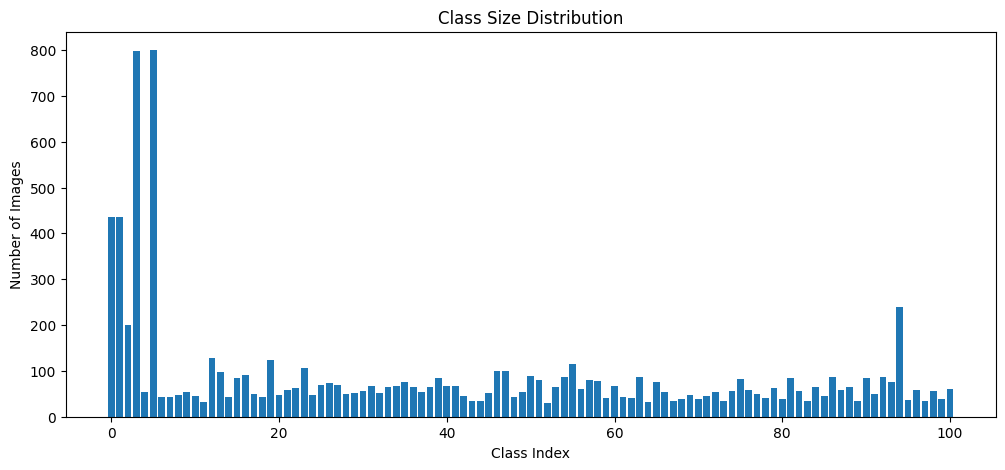

In [33]:
#Class distribution
root = Path(ROOT_DIR)

class_sizes = defaultdict(int)
max_class_size = float('-inf')
min_class_size = float('inf')


class_counts = Counter(labels)

print("Number of classes:", len(class_counts))
print("Min class size:", min(class_counts.values()))
print("Max class size:", max(class_counts.values()))



counts = list(class_counts.values())

plt.figure(figsize=(12,5))
plt.bar(range(len(counts)), counts)
plt.title("Class Size Distribution")
plt.xlabel("Class Index")
plt.ylabel("Number of Images")
plt.show()

In [34]:
#Compute Image Dimensions
heights = []
widths = []

for path in tqdm(paths):
    with Image.open(path) as img:
        w, h = img.size  # PIL gives (width, height)
        widths.append(w)
        heights.append(h)

heights = np.array(heights)
widths = np.array(widths)

100%|██████████| 8677/8677 [00:00<00:00, 14958.51it/s]


In [35]:
#Statistics
print("Height stats:")
print("  Min:", heights.min())
print("  Max:", heights.max())
print("  Mean:", heights.mean())

print("\nWidth stats:")
print("  Min:", widths.min())
print("  Max:", widths.max())
print("  Mean:", widths.mean())

Height stats:
  Min: 92
  Max: 494
  Mean: 239.5194191540855

Width stats:
  Min: 80
  Max: 708
  Mean: 297.7595943298375


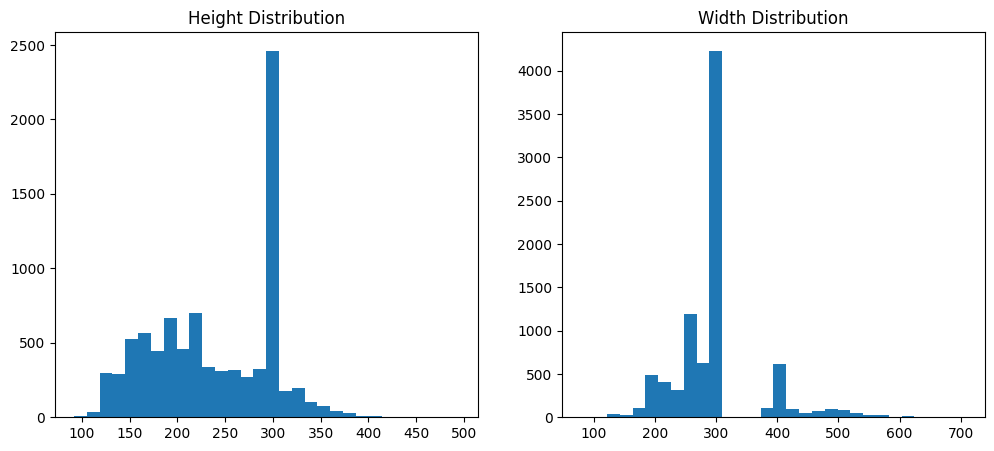

In [36]:
#Plots

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(heights, bins=30)
plt.title("Height Distribution")

plt.subplot(1,2,2)
plt.hist(widths, bins=30)
plt.title("Width Distribution")

plt.show()